# Film-Level Dataset Preparation

In diesem Notebook wird der Review-Level-Datensatz auf Filmebene aggregiert.

Ziel ist es, einen bereinigten Film-Level-Datensatz für die spätere Regressionsanalyse zu erstellen.

Die Review-Daten enthalten bereits Emotionsscores und die finale Intensitätsklasse aus dem Klassifikationsmodell.

# Imports & Daten

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [75]:
reviews = pd.read_csv(
    "../Dataset/reviews_with_emotions_and_intensity_classes.csv"
)

movies = pd.read_csv(
    "../Dataset/rotten_tomatoes_movies.csv"
)

In [76]:
print("Reviews:", reviews.shape)
print("Movies:", movies.shape)

Reviews: (1323533, 22)
Movies: (143258, 16)


In [77]:
# Missing Values kurz prüfen
reviews[
    [
        "id",
        "reviewText",
        "neutral",
        "joy",
        "anger",
        "fear",
        "sadness",
        "surprise",
        "disgust",
        "emotion_structure_final"
    ]
].isna().sum()

id                         0
reviewText                 0
neutral                    0
joy                        0
anger                      0
fear                       0
sadness                    0
surprise                   0
disgust                    0
emotion_structure_final    0
dtype: int64

In [78]:
# Missing Values kurz prüfen
movies[
    [
        "id",
        "title",
        "tomatoMeter",
        "audienceScore"
    ]
].isna().sum()

id                    0
title               367
tomatoMeter      109381
audienceScore     70010
dtype: int64

# Aggregation auf Filmebene

Für die Regressionsanalyse werden die Review-Daten auf Filmebene aggregiert.

Für jeden Film berechnen wir:
- durchschnittliche Emotionswerte,
- Streuung der emotionalen Intensität,
- Anzahl der Reviews,
- Anteil der Reviews pro Intensitätsklasse.

## Durchschnittliche Emotionswerte

In [79]:
emotion_cols = [
    "joy",
    "anger",
    "fear",
    "sadness",
    "surprise",
    "disgust",
    "neutral"
]

film_emotions_mean = (
    reviews
    .groupby("id")[emotion_cols]
    .mean()
    .add_suffix("_mean")
)

## Streuung der emotionalen Intensität

In [80]:
film_neutral_std = (
    reviews
    .groupby("id")["neutral"]
    .std()
    .rename("neutral_std")
)

## Anzahl der Reviews

In [81]:
film_review_count = (
    reviews
    .groupby("id")
    .size()
    .rename("num_reviews")
)

## Anteil der Reviews pro Intensitätsklasse

In [82]:
film_intensity_shares = (
    pd.crosstab(
        reviews["id"],
        reviews["emotion_structure_final"],
        normalize="index"
    )
    .rename(
        columns={
            "low": "share_low",
            "medium": "share_medium",
            "high": "share_high"
        }
    )
)

## Concatination

Für Filme mit nur einem Review kann keine Standardabweichung berechnet werden.

Deshalb wird `neutral_std` in diesen Fällen auf 0 gesetzt.

Da die finale Intensitätsklasse direkt auf dem Neutral-Score basiert, wird keine separate Variable `emotional_intensity` verwendet.

In [83]:
film_emotions = pd.concat(
    [
        film_emotions_mean,
        film_neutral_std,
        film_review_count,
        film_intensity_shares
    ],
    axis=1
).reset_index()

film_emotions.head()

,id,joy_mean,anger_mean,fear_mean,sadness_mean,surprise_mean,disgust_mean,neutral_mean,neutral_std,num_reviews,share_high,share_low,share_medium
0,$5_a_day,0.075821,0.019381,0.014432,0.095289,0.006426,0.070745,0.717905,0.235665,3,0.000000,0.666667,0.333333
1,009_re_cyborg,0.177228,0.052952,0.107659,0.112802,0.057184,0.226962,0.265214,0.265032,13,0.461538,0.153846,0.384615
2,00_mhz,0.525107,0.013021,0.053679,0.110953,0.097697,0.010615,0.188928,0.264705,3,0.666667,0.000000,0.333333
3,0814255,0.295890,0.026478,0.043374,0.065095,0.051839,0.115734,0.401590,0.341333,143,0.279720,0.321678,0.398601
4,0878835,0.371708,0.028572,0.033954,0.062944,0.039601,0.087643,0.375578,0.311465,139,0.237410,0.251799,0.510791


In [84]:
film_emotions["neutral_std"] = (
    film_emotions["neutral_std"]
    .fillna(0)
)

# Merge mit Movie-Metadaten

Im nächsten Schritt werden die aggregierten Emotionsmerkmale mit den Metadaten aus dem Rotten-Tomatoes-Filmdatensatz verbunden.

Die Verbindung erfolgt über die gemeinsame Spalte `id`.

In [85]:
movies.columns.tolist()

['id',
 'title',
 'audienceScore',
 'tomatoMeter',
 'rating',
 'ratingContents',
 'releaseDateTheaters',
 'releaseDateStreaming',
 'runtimeMinutes',
 'genre',
 'originalLanguage',
 'director',
 'writer',
 'boxOffice',
 'distributor',
 'soundMix']

In [86]:
# Bereinigung der Duplicates

movies = movies.drop_duplicates(subset="id")

In [87]:
film_level = film_emotions.merge(
    movies,
    on="id",
    how="left"
)

film_level.shape

(66514, 28)

# Bereinigung

## Entfernen von Variablen mit geringem Nutzen

In [88]:
film_level.info()

<class 'pandas.DataFrame'>
RangeIndex: 66514 entries, 0 to 66513
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    66514 non-null  str    
 1   joy_mean              66514 non-null  float64
 2   anger_mean            66514 non-null  float64
 3   fear_mean             66514 non-null  float64
 4   sadness_mean          66514 non-null  float64
 5   surprise_mean         66514 non-null  float64
 6   disgust_mean          66514 non-null  float64
 7   neutral_mean          66514 non-null  float64
 8   neutral_std           66514 non-null  float64
 9   num_reviews           66514 non-null  int64  
 10  share_high            66514 non-null  float64
 11  share_low             66514 non-null  float64
 12  share_medium          66514 non-null  float64
 13  title                 66333 non-null  str    
 14  audienceScore         48450 non-null  float64
 15  tomatoMeter           33293 no

In [89]:
# TomatoMeter Filter

film_level = film_level.dropna(
    subset=["tomatoMeter"]
).copy()

In [90]:
film_level.info()

<class 'pandas.DataFrame'>
Index: 33293 entries, 1 to 66513
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    33293 non-null  str    
 1   joy_mean              33293 non-null  float64
 2   anger_mean            33293 non-null  float64
 3   fear_mean             33293 non-null  float64
 4   sadness_mean          33293 non-null  float64
 5   surprise_mean         33293 non-null  float64
 6   disgust_mean          33293 non-null  float64
 7   neutral_mean          33293 non-null  float64
 8   neutral_std           33293 non-null  float64
 9   num_reviews           33293 non-null  int64  
 10  share_high            33293 non-null  float64
 11  share_low             33293 non-null  float64
 12  share_medium          33293 non-null  float64
 13  title                 33293 non-null  str    
 14  audienceScore         29810 non-null  float64
 15  tomatoMeter           33293 non-nul

In [91]:
'''
"rating" - 73% leer
"ratingContents" - 73% leer,
"boxOffice" - 61% leer,
"soundMix" - 71% leer,
"distributor  - fast 50% leer"
'''

film_level = film_level.drop(
    columns=[
        "rating",
        "ratingContents",
        "boxOffice",
        "soundMix",
        "distributor"
    ]
)

In [92]:
film_level.info()

<class 'pandas.DataFrame'>
Index: 33293 entries, 1 to 66513
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    33293 non-null  str    
 1   joy_mean              33293 non-null  float64
 2   anger_mean            33293 non-null  float64
 3   fear_mean             33293 non-null  float64
 4   sadness_mean          33293 non-null  float64
 5   surprise_mean         33293 non-null  float64
 6   disgust_mean          33293 non-null  float64
 7   neutral_mean          33293 non-null  float64
 8   neutral_std           33293 non-null  float64
 9   num_reviews           33293 non-null  int64  
 10  share_high            33293 non-null  float64
 11  share_low             33293 non-null  float64
 12  share_medium          33293 non-null  float64
 13  title                 33293 non-null  str    
 14  audienceScore         29810 non-null  float64
 15  tomatoMeter           33293 non-nul

In [93]:
missing = (
    film_level.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

missing

releaseDateTheaters     41.8
writer                  21.2
releaseDateStreaming    15.4
audienceScore           10.5
runtimeMinutes           3.6
originalLanguage         3.4
genre                    2.4
director                 0.5
share_medium             0.0
tomatoMeter              0.0
title                    0.0
id                       0.0
joy_mean                 0.0
share_high               0.0
num_reviews              0.0
neutral_std              0.0
neutral_mean             0.0
disgust_mean             0.0
surprise_mean            0.0
sadness_mean             0.0
fear_mean                0.0
anger_mean               0.0
share_low                0.0
dtype: float64

In [94]:
'''
"releaseDateTheaters" etwa 42 % der Filme fehlende Werte.

"releaseDateStreaming" enthält ebenfalls viele fehlende Werte (ca. 15 %).

Beide Variablen liegen als Datumsangaben vor und müssten zunächst in aussagekräftige numerische Merkmale (z. B. Erscheinungsjahr oder Filmalter) umgewandelt werden.

Da der Schwerpunkt dieses Projekts auf dem Zusammenhang zwischen Emotionen in Rezensionen und dem `tomatoMeter` liegt, werden diese Variablen zunächst ausgeschlossen.

Sie können in zukünftigen Modellerweiterungen wieder berücksichtigt werden

'''

film_level = film_level.drop(
    columns=[
        "releaseDateTheaters",
        "releaseDateStreaming"
    ]
)

film_level.info()

<class 'pandas.DataFrame'>
Index: 33293 entries, 1 to 66513
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                33293 non-null  str    
 1   joy_mean          33293 non-null  float64
 2   anger_mean        33293 non-null  float64
 3   fear_mean         33293 non-null  float64
 4   sadness_mean      33293 non-null  float64
 5   surprise_mean     33293 non-null  float64
 6   disgust_mean      33293 non-null  float64
 7   neutral_mean      33293 non-null  float64
 8   neutral_std       33293 non-null  float64
 9   num_reviews       33293 non-null  int64  
 10  share_high        33293 non-null  float64
 11  share_low         33293 non-null  float64
 12  share_medium      33293 non-null  float64
 13  title             33293 non-null  str    
 14  audienceScore     29810 non-null  float64
 15  tomatoMeter       33293 non-null  float64
 16  runtimeMinutes    32084 non-null  float64
 17  genre    

In [102]:
"""
Fehlende Laufzeit und audienceScore

Da die Laufzeit und audienceScore als numerisches Merkmal im Regressionsmodell verwendet werden,
werden Filme ohne Angabe der Laufzeit/audienceScore entfernt.

Nur etwa 3–4 % der Filme sind betroffen, sodass der Informationsverlust gering ist.
"""
film_level = film_level.dropna(subset=[
    "runtimeMinutes",
    "audienceScore"
])

film_level.shape

(29130, 21)

## Analyse. Anzahl der Reviews

In [103]:
film_level["num_reviews"].describe()

count    29130.000000
mean        41.770203
std         61.012642
min          1.000000
25%          7.000000
50%         16.000000
75%         47.000000
max        590.000000
Name: num_reviews, dtype: float64

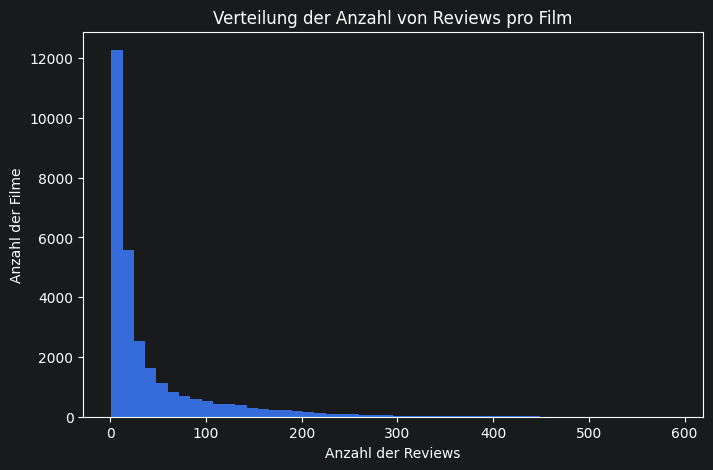

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(film_level["num_reviews"], bins=50)

plt.xlabel("Anzahl der Reviews")
plt.ylabel("Anzahl der Filme")
plt.title("Verteilung der Anzahl von Reviews pro Film")

plt.show()

In [105]:
for threshold in [5, 10, 20]:
    n = (film_level["num_reviews"] >= threshold).sum()
    print(f">= {threshold} Reviews: {n} Filme ({n/len(film_level):.1%})")

>= 5 Reviews: 26854 Filme (92.2%)
>= 10 Reviews: 19486 Filme (66.9%)
>= 20 Reviews: 13044 Filme (44.8%)


### Filter nach der Anzahl der Reviews

Die aggregierten Emotionsmerkmale basieren auf den Mittelwerten aller Rezensionen eines Films.

Filme mit weniger als 10 Reviews können instabile Emotionsprofile aufweisen. Deshalb werden für die Regressionsanalyse nur Filme mit mindestens 10 Reviews verwendet.

Der vollständige Datensatz bleibt zusätzlich erhalten und wird ebenfalls gespeichert.

In [106]:
film_level_clean = film_level[
    film_level["num_reviews"] >= 10
].copy()

film_level_clean.shape

(19486, 21)

In [107]:
print(f"Vollständiger Datensatz: {len(film_level):,} Filme")
print(f"Bereinigter Datensatz:   {len(film_level_clean):,} Filme")

Vollständiger Datensatz: 29,130 Filme
Bereinigter Datensatz:   19,486 Filme


In [108]:
film_level.to_csv(
    "../Dataset/film_level_full.csv",
    index=False
)

film_level_clean.to_csv(
    "../Dataset/film_level_clean.csv",
    index=False
)

print("Film-Level-Datensätze erfolgreich gespeichert.")

Film-Level-Datensätze erfolgreich gespeichert.


# Genre Bearbeitung

In [117]:
film_level_clean["genre"].head(10)

1                    Action, Sci-fi, Animation
6                                        Drama
8                              Romance, Comedy
9                                        Drama
14                     Drama, Musical, Romance
18                                Crime, Drama
19    Kids & family, Drama, Adventure, Fantasy
21                    Adventure, Action, Drama
23                              Romance, Drama
31                          Mystery & thriller
Name: genre, dtype: str

In [118]:
film_level_clean["genre"].nunique()

1303

In [119]:
film_level_clean["originalLanguage"].value_counts().head(20)

originalLanguage
English                     14955
French (France)               511
English (United Kingdom)      476
French (Canada)               430
Hindi                         324
Spanish                       299
Japanese                      295
Chinese                       254
German                        207
Italian                       178
Korean                        139
Arabic                        115
English (Australia)           110
Spanish (Spain)               106
Russian                        87
Portuguese (Brazil)            84
Swedish                        69
Danish                         64
Hebrew                         64
Persian                        60
Name: count, dtype: int64

In [120]:
genres = film_level_clean["genre"].str.get_dummies(sep=", ")

In [121]:
languages = pd.get_dummies(
    film_level_clean["originalLanguage"],
    prefix="lang",
    drop_first=True
)

In [122]:
genres.shape

(19486, 28)

In [123]:
genres.columns.tolist()

['Action',
 'Adventure',
 'Animation',
 'Anime',
 'Biography',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Foreign',
 'History',
 'Holiday',
 'Horror',
 'Kids & family',
 'Lgbtq+',
 'Music',
 'Musical',
 'Mystery & thriller',
 'Nature',
 'Romance',
 'Sci-fi',
 'Short',
 'Sports',
 'Sports & fitness',
 'Stand-up',
 'War',
 'Western']

In [124]:
film_level_clean = pd.concat(
    [film_level_clean, genres],
    axis=1
)

In [128]:
# Liste aller Genre-Features speichern
genre_features = genres.columns.tolist()

In [129]:
print(len(genre_features))

28


In [137]:
import json

with open("../Dataset/genre_features.json", "w") as f:
    json.dump(genre_features, f)

In [138]:
film_level_clean.to_csv(
    "../Dataset/film_level_clean.csv",
    index=False
)

print("Film-Level-Datensätze erfolgreich gespeichert.")

Film-Level-Datensätze erfolgreich gespeichert.


In [139]:
film_level_clean.shape

(19486, 49)

In [140]:
film_level_clean.columns

Index(['id', 'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
       'surprise_mean', 'disgust_mean', 'neutral_mean', 'neutral_std',
       'num_reviews', 'share_high', 'share_low', 'share_medium', 'title',
       'audienceScore', 'tomatoMeter', 'runtimeMinutes', 'genre',
       'originalLanguage', 'director', 'writer', 'Action', 'Adventure',
       'Animation', 'Anime', 'Biography', 'Comedy', 'Crime', 'Documentary',
       'Drama', 'Fantasy', 'Foreign', 'History', 'Holiday', 'Horror',
       'Kids & family', 'Lgbtq+', 'Music', 'Musical', 'Mystery & thriller',
       'Nature', 'Romance', 'Sci-fi', 'Short', 'Sports', 'Sports & fitness',
       'Stand-up', 'War', 'Western'],
      dtype='str')